# MonReader: evaluating page-flip detection across video groups

This project studies one part of the MonReader document-scanning problem: **classifying a single image as `flip` or `notflip`**. It was developed in the context of the [Apziva](https://www.apziva.com/) AI Residency using the supplied labeled frames.

The central question is whether a model can recognize a page flip in frames from **video IDs excluded from training**. A high score on a frame-level split does not answer that question if related frames appear on both sides of the split.

The implementation below audits the data, evaluates a fixed logistic-regression baseline against an always-flip reference, inspects validation errors, and reports the supplied test benchmark separately. It includes executable evidence for each result. The completed scope is a baseline experiment; sequence detection, OCR, and mobile deployment are outside this implementation.

**Reading order:** data audit -> validation design -> image features -> grouped evaluation -> error analysis -> supplied test benchmark -> inference -> exported evidence -> conclusions.

**Run:** open this folder in VS Code, select the Python kernel described in `requirements.txt`, and run all cells in order. The notebook reads local `images/` and writes generated artifacts to `outputs/` and `reports/`. The README provides setup instructions.


In [1]:
from pathlib import Path
import hashlib
import json
import platform
import re

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import PIL
import sklearn
from PIL import Image, ImageOps
from IPython.display import display
from sklearn.base import clone
from sklearn.dummy import DummyClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    ConfusionMatrixDisplay, classification_report, f1_score,
    precision_score, recall_score,
)
from sklearn.model_selection import StratifiedGroupKFold
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from threadpoolctl import threadpool_limits

SEED = 42
ROOT = Path.cwd()
DATA = ROOT / "images"
OUTPUT = ROOT / "outputs"
OUTPUT.mkdir(exist_ok=True)
assert DATA.is_dir(), "Open/run the notebook from the folder containing images/."
LABELS = {"notflip": 0, "flip": 1}
CLASS_NAMES = ["notflip", "flip"]
print("Python:", platform.python_version())
print("scikit-learn:", sklearn.__version__)


Python: 3.14.6
scikit-learn: 1.9.0


## 1. Audit the dataset

The supplied folders define the labels: `notflip = 0`, `flip = 1`. The documented filename pattern is `VideoID_FrameNumber.jpg`. The inventory preserves video IDs and frame numbers for evaluation, but does not use either as a model input.

Every image is decoded to check for unreadable data. File dimensions, color mode, and SHA-256 hashes are recorded. Hashes detect identical files; they do not rule out near-duplicate images or the same image stored with different compression.

Inspecting test-folder metadata here is a split-integrity check. The test labels are not used to fit preprocessing, choose hyperparameters, or adjust the classification threshold.


In [2]:
records = []
for split in ["training", "testing"]:
    for label, target in LABELS.items():
        folder = DATA / split / label
        assert folder.is_dir(), f"Missing folder: {folder}"
        paths = sorted(folder.glob("*.jpg"))
        assert paths, f"No JPG images in {folder}"
        for path in paths:
            match = re.fullmatch(r"(\d+)_(\d+)", path.stem)
            assert match, f"Unexpected filename: {path.name}"
            with Image.open(path) as img:
                img.load()  # Detect truncated/corrupt images, not just bad headers.
                width, height = img.size
                mode = img.mode
            records.append({
                "path": path, "split": split, "label": label, "target": target,
                "video_id": match.group(1), "frame": int(match.group(2)),
                "width": width, "height": height, "mode": mode,
                "sha256": hashlib.sha256(path.read_bytes()).hexdigest(),
            })

df = pd.DataFrame(records)
display(pd.crosstab(df["split"], df["label"]))
display(df.groupby(["width", "height", "mode"]).size().rename("images").to_frame())
print(f"Successfully decoded {len(df):,} images.")
assert df.groupby("sha256")["target"].nunique().max() == 1, "Conflicting duplicate labels."


label,flip,notflip
split,,
testing,290,307
training,1162,1230


,,,images
width,height,mode,
1080,1920,RGB,2989


Successfully decoded 2,989 images.


## 2. Inspect training examples

The grid uses only training images. Visible page curvature and blurred page edges are plausible signals, while hands, backgrounds, or book layouts could become shortcuts. These are visual observations and hypotheses; they do not establish what the fitted model actually uses.

The deterministic sample makes the initial inspection repeatable.


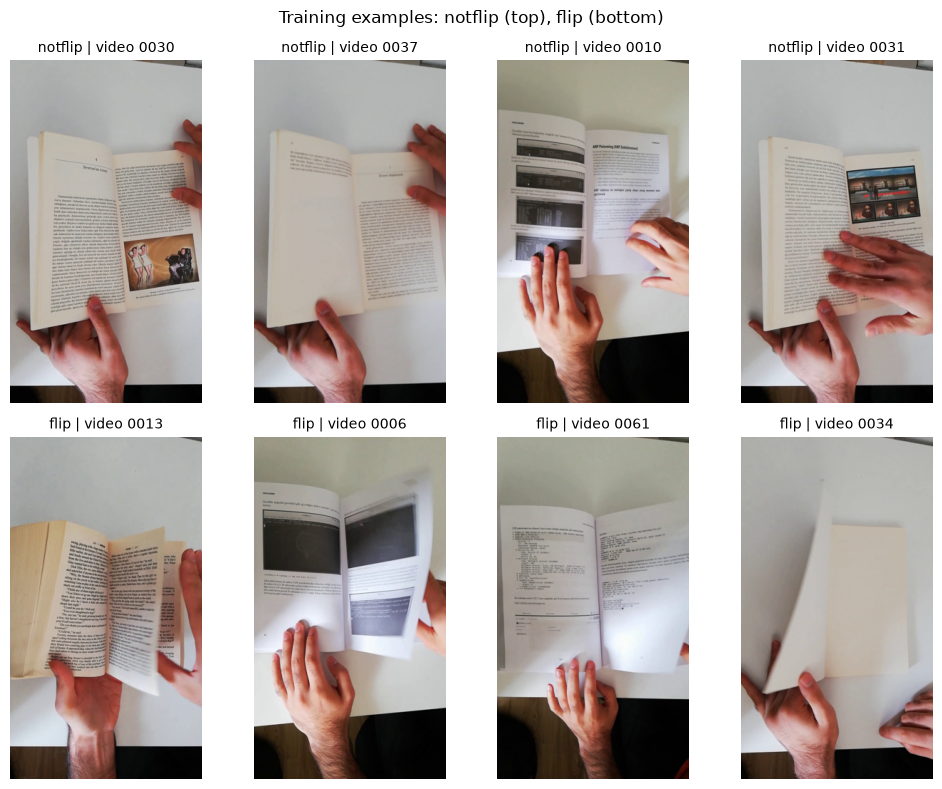

In [3]:
train = df.loc[df["split"].eq("training")].reset_index(drop=True)
test = df.loc[df["split"].eq("testing")].reset_index(drop=True)
fig, axes = plt.subplots(2, 4, figsize=(10, 8))
for row, label in enumerate(CLASS_NAMES):
    samples = train.loc[train["label"].eq(label)].sample(4, random_state=SEED)
    for ax, sample in zip(axes[row], samples.itertuples()):
        with Image.open(sample.path) as img:
            preview = ImageOps.exif_transpose(img).convert("RGB")
            preview.thumbnail((270, 480))
        ax.imshow(preview)
        ax.set_title(f"{label} | video {sample.video_id}", fontsize=10)
        ax.axis("off")
fig.suptitle("Training examples: notflip (top), flip (bottom)")
fig.tight_layout()
fig.savefig(OUTPUT / "training_examples.png", dpi=120)
plt.show()


## 3. Define what validation measures

Two evaluation protocols answer different questions:

| Protocol | Fitting data | Evaluation data | Interpretation |
| --- | --- | --- | --- |
| Five-fold grouped validation | Four folds of the supplied training folder | Remaining fold, with disjoint video IDs | Performance on held-out video IDs within this dataset |
| Supplied test benchmark | All supplied training images | Supplied testing folder | Performance on held-out frames; check video overlap below |

`StratifiedGroupKFold` keeps groups separate while attempting to maintain class proportions ([documentation](https://scikit-learn.org/stable/modules/generated/sklearn.model_selection.StratifiedGroupKFold.html)). We use the filename video ID as the group, five folds, and seed 42. Assertions check that validation groups and exact file hashes do not overlap their corresponding fitting fold.

**Assumption:** IDs identify videos consistently across folders, as described in the brief. This is not independently verified provenance. Even distinct video IDs may share a book, device, or recording session, so this protocol cannot establish generalization to entirely new capture conditions.


In [4]:
shared_videos = sorted(set(train["video_id"]) & set(test["video_id"]))
shared_hashes = set(train["sha256"]) & set(test["sha256"])
print("Training video IDs:", train["video_id"].nunique())
print("Testing video IDs:", test["video_id"].nunique())
print("Video IDs shared across supplied folders:", len(shared_videos))
print("Exact file hashes shared across supplied folders:", len(shared_hashes))
print("Repeated file hashes across all images:", int(df["sha256"].duplicated().sum()))
if shared_videos:
    print("The supplied test score is a same-video frame benchmark, not an unseen-video estimate.")

cv = StratifiedGroupKFold(n_splits=5, shuffle=True, random_state=SEED)
folds = list(cv.split(train, train["target"], groups=train["video_id"]))
fold_details = []
for fold, (fit_idx, val_idx) in enumerate(folds, start=1):
    fit_rows, val_rows = train.iloc[fit_idx], train.iloc[val_idx]
    assert set(fit_rows["video_id"]).isdisjoint(val_rows["video_id"])
    assert set(fit_rows["sha256"]).isdisjoint(val_rows["sha256"]), "Exact duplicates cross validation groups."
    assert fit_rows["target"].nunique() == val_rows["target"].nunique() == 2
    fold_details.append({"fold": fold, "fit_images": len(fit_rows),
                         "validation_images": len(val_rows),
                         "validation_videos": val_rows["video_id"].nunique(),
                         "validation_flip_fraction": val_rows["target"].mean()})
display(pd.DataFrame(fold_details).round(3))


Training video IDs: 65
Testing video IDs: 65
Video IDs shared across supplied folders: 65
Exact file hashes shared across supplied folders: 0
Repeated file hashes across all images: 0
The supplied test score is a same-video frame benchmark, not an unseen-video estimate.


,fold,fit_images,validation_images,validation_videos,validation_flip_fraction
0,1,1899,493,12,0.471
1,2,1902,490,14,0.471
2,3,1915,477,14,0.503
3,4,1910,482,13,0.485
4,5,1942,450,12,0.500


## 4. Define the image representation

Each image is converted to grayscale, resized to **36 pixels wide by 64 pixels tall**, and flattened into 2,304 values scaled to [0, 1]. This preserves the supplied images' 9:16 aspect ratio. Inference on a differently proportioned image would stretch it to this fixed shape.

The representation provides a small CPU-compatible baseline with no pretrained weights. It discards fine detail and is sensitive to spatial alignment. No augmentation or feature search is performed.


In [5]:
IMAGE_SIZE = (36, 64)  # Pillow uses (width, height).

def image_features(path):
    with Image.open(path) as img:
        img = ImageOps.exif_transpose(img).convert("L")
        img = img.resize(IMAGE_SIZE, Image.Resampling.BILINEAR)
        return np.asarray(img, dtype=np.float32).reshape(-1) / 255.0

X_train = np.stack([image_features(path) for path in train["path"]])
y_train = train["target"].to_numpy()
assert np.isfinite(X_train).all()
print("Training matrix (images, features):", X_train.shape)


Training matrix (images, features): (2392, 2304)


## 5. Evaluate a predefined model and reference rule

The reference always predicts `flip`. It has perfect flip recall but produces false positives, so it provides a useful minimum comparison for the chosen metric.

The learned baseline uses `StandardScaler` followed by logistic regression with `C=0.01`, `solver="liblinear"`, `max_iter=2000`, and seed 42. A fresh pipeline is fitted inside each fold; validation frames do not influence the scaler's fitted statistics ([pipeline guidance](https://scikit-learn.org/stable/common_pitfalls.html#data-leakage)). The probability threshold is fixed at 0.5. These settings were chosen before the first evaluation; the reporting revision does not retune them.

**Metric:** binary F1 for the positive class `flip`, with precision and recall reported separately. Precision measures the fraction of flip predictions that are correct; recall measures the fraction of actual flips detected. `F1 = 2 TP / (2 TP + FP + FN)` ([definition](https://scikit-learn.org/stable/modules/generated/sklearn.metrics.f1_score.html)). F1 is not accuracy.


In [6]:
baseline = make_pipeline(
    StandardScaler(),
    LogisticRegression(C=0.01, solver="liblinear", max_iter=2000, random_state=SEED),
)
models = {
    "always_flip": DummyClassifier(strategy="constant", constant=1),
    "logistic_pixels": baseline,
}
fold_scores = []
oof_predictions = {}
for name, template in models.items():
    predictions = np.full(len(train), -1, dtype=int)
    for fold, (fit_idx, val_idx) in enumerate(folds, start=1):
        model = clone(template)
        with threadpool_limits(limits=2):
            model.fit(X_train[fit_idx], y_train[fit_idx])
            predictions[val_idx] = model.predict(X_train[val_idx])
        fold_scores.append({"model": name, "fold": fold,
                            "f1": f1_score(y_train[val_idx], predictions[val_idx], zero_division=0)})
    assert (predictions >= 0).all()
    oof_predictions[name] = predictions

fold_scores = pd.DataFrame(fold_scores)
validation_results = pd.DataFrame([
    {"model": name,
     "pooled_oof_f1": f1_score(y_train, pred, zero_division=0),
     "precision": precision_score(y_train, pred, zero_division=0),
     "recall": recall_score(y_train, pred, zero_division=0)}
    for name, pred in oof_predictions.items()
]).set_index("model").join(fold_scores.groupby("model")["f1"].agg(["mean", "std"]).rename(
    columns={"mean": "fold_mean_f1", "std": "fold_std_f1"}))
display(validation_results.round(4))
display(fold_scores.pivot(index="fold", columns="model", values="f1").round(4))
validation_results.to_csv(OUTPUT / "validation_metrics.csv")
fold_scores.to_csv(OUTPUT / "fold_metrics.csv", index=False)


,pooled_oof_f1,precision,recall,fold_mean_f1,fold_std_f1
model,,,,,
always_flip,0.6539,0.4858,1.0000,0.6541,0.0139
logistic_pixels,0.8568,0.8276,0.8881,0.8586,0.0517


model,always_flip,logistic_pixels
fold,,
1,0.6400,0.8470
2,0.6408,0.8327
3,0.6695,0.8040
4,0.6536,0.8680
5,0.6667,0.9412


### Reading the grouped results

Each out-of-fold (OOF) prediction is generated by a model that excluded the corresponding video ID from fitting. The **pooled OOF F1** combines predictions across all 2,392 training frames. It weights frames through pooled counts, not videos equally. The **fold mean** averages five F1 scores; it need not equal the pooled score. Fold standard deviation describes variation across these particular folds and is not a confidence interval.

The grouped estimate measures held-out IDs within the available data. Once these results guide subsequent model choices, they are development evidence. A future final evaluation should reserve independent videos, preferably with known recording-session provenance.


## 6. Inspect validation errors

The confusion matrix summarizes OOF predictions with `flip` as the positive class. The sampled mistakes come from this same grouped validation, so they can guide further investigation without using test images for model selection.

The completed baseline has **215 false positives** and **130 false negatives**. These correspond to 345 errors among 2,392 OOF predictions. Visually subtle page movement and hand motion are possible sources of ambiguity; this sample is not a systematic annotation audit or a causal explanation of the errors.


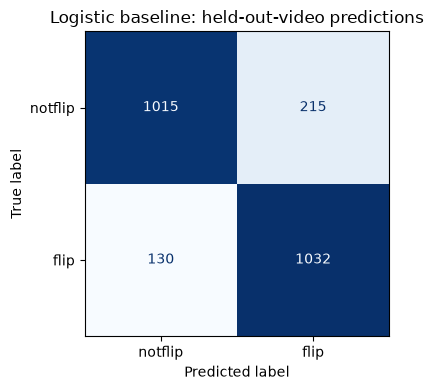

              precision    recall  f1-score   support

     notflip       0.89      0.83      0.85      1230
        flip       0.83      0.89      0.86      1162

    accuracy                           0.86      2392
   macro avg       0.86      0.86      0.86      2392
weighted avg       0.86      0.86      0.86      2392



In [7]:
fig, ax = plt.subplots(figsize=(5, 4))
ConfusionMatrixDisplay.from_predictions(
    y_train, oof_predictions["logistic_pixels"], labels=[0, 1],
    display_labels=CLASS_NAMES, cmap="Blues", colorbar=False, ax=ax,
)
ax.set_title("Logistic baseline: held-out-video predictions")
fig.tight_layout()
fig.savefig(OUTPUT / "validation_confusion_matrix.png", dpi=120)
plt.show()
print(classification_report(y_train, oof_predictions["logistic_pixels"],
                            labels=[0, 1], target_names=CLASS_NAMES, zero_division=0))


Validation mistakes: 345 / 2392


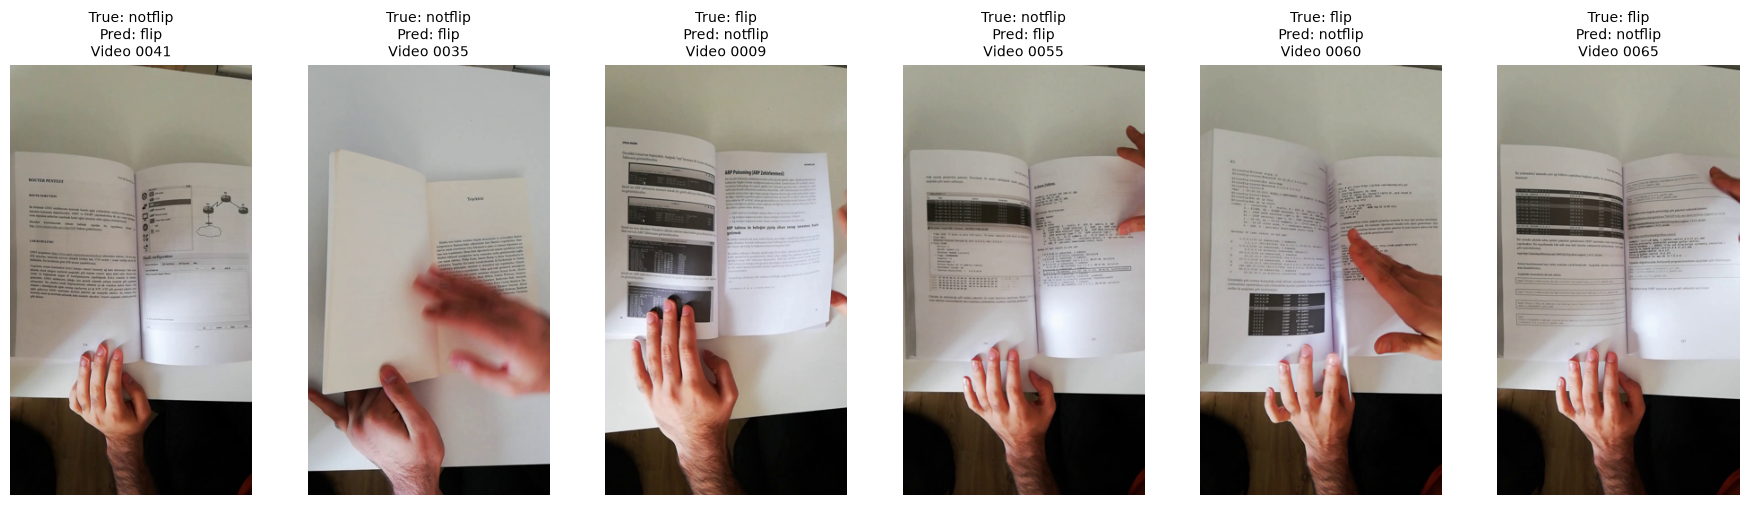

In [8]:
errors = train.loc[oof_predictions["logistic_pixels"] != y_train].copy()
errors["predicted"] = oof_predictions["logistic_pixels"][errors.index]
print(f"Validation mistakes: {len(errors)} / {len(train)}")
if len(errors):
    samples = errors.sample(min(6, len(errors)), random_state=SEED)
    fig, axes = plt.subplots(1, len(samples), figsize=(3 * len(samples), 5), squeeze=False)
    for ax, sample in zip(axes.flat, samples.itertuples()):
        with Image.open(sample.path) as img:
            preview = ImageOps.exif_transpose(img).convert("RGB")
            preview.thumbnail((270, 480))
        ax.imshow(preview)
        ax.set_title(f"True: {sample.label}\nPred: {CLASS_NAMES[sample.predicted]}\nVideo {sample.video_id}", fontsize=10)
        ax.axis("off")
    fig.tight_layout()
    fig.savefig(OUTPUT / "validation_errors.png", dpi=120)
    plt.show()


## 7. Report the supplied test benchmark separately

The same fixed model is fitted on all 2,392 supplied training images, then evaluated on the 597 supplied test images. This preserves the provided benchmark without presenting it as a new-video evaluation.

All 65 filename video IDs occur in both supplied folders. Related frames may therefore share visual context across the split. The difference between this benchmark and grouped validation is **not an isolated measurement of leakage**: the evaluated frames and the amount of fitting data also differ. It does establish that the two scores should not be treated as interchangeable.

Re-running this notebook reproduces the same fixed experiment; it is not an additional independent test. Further tuning should use training-only grouped validation rather than this test score.


In [9]:
final_model = clone(baseline)
with threadpool_limits(limits=2):
    final_model.fit(X_train, y_train)
X_test = np.stack([image_features(path) for path in test["path"]])
y_test = test["target"].to_numpy()
test_probability = final_model.predict_proba(X_test)[:, 1]
test_prediction = (test_probability >= 0.5).astype(int)
test_metrics = {
    "f1": float(f1_score(y_test, test_prediction, zero_division=0)),
    "precision": float(precision_score(y_test, test_prediction, zero_division=0)),
    "recall": float(recall_score(y_test, test_prediction, zero_division=0)),
    "always_flip_f1": float(f1_score(y_test, np.ones_like(y_test), zero_division=0)),
    "shared_video_ids": len(shared_videos),
    "shared_exact_hashes": len(shared_hashes),
    "interpretation": "Supplied frame benchmark; video IDs overlap training.",
}
print(json.dumps(test_metrics, indent=2))
print(classification_report(y_test, test_prediction, labels=[0, 1],
                            target_names=CLASS_NAMES, zero_division=0))
_ = (OUTPUT / "test_metrics.json").write_text(json.dumps(test_metrics, indent=2), encoding="utf-8")


{
  "f1": 0.9772329246935202,
  "precision": 0.9928825622775801,
  "recall": 0.9620689655172414,
  "always_flip_f1": 0.6538895152198422,
  "shared_video_ids": 65,
  "shared_exact_hashes": 0,
  "interpretation": "Supplied frame benchmark; video IDs overlap training."
}
              precision    recall  f1-score   support

     notflip       0.97      0.99      0.98       307
        flip       0.99      0.96      0.98       290

    accuracy                           0.98       597
   macro avg       0.98      0.98      0.98       597
weighted avg       0.98      0.98      0.98       597



## 8. Save and reuse the baseline

The model bundle stores the fitted pipeline, resize dimensions, label mapping, threshold, and library versions. `predict_image` applies the same preprocessing used for fitting. Its probability is a model estimate; calibration has not been evaluated.

The example below uses an existing test image as an inference demonstration. It is not additional validation on an external image. Load joblib model files only from trusted sources.


In [10]:
bundle = {"model": final_model, "image_size": IMAGE_SIZE, "class_names": CLASS_NAMES,
          "threshold": 0.5, "grayscale": True, "seed": SEED,
          "versions": {"python": platform.python_version(), "sklearn": sklearn.__version__,
                       "numpy": np.__version__, "pillow": PIL.__version__}}
joblib.dump(bundle, OUTPUT / "baseline_model.joblib")

def predict_image(path):
    features = image_features(Path(path)).reshape(1, -1)
    probability = float(final_model.predict_proba(features)[0, 1])
    return {"label": CLASS_NAMES[int(probability >= 0.5)], "flip_probability": probability}

example_path = test.iloc[0]["path"]
print(example_path.name, predict_image(example_path))
# Try a different image: predict_image("path/to/your/image.jpg")

predictions = test[["path", "video_id", "frame", "label"]].copy()
predictions["path"] = predictions["path"].map(lambda path: path.relative_to(ROOT).as_posix())
predictions["flip_probability"] = test_probability
predictions["prediction"] = [CLASS_NAMES[value] for value in test_prediction]
predictions.to_csv(OUTPUT / "test_predictions.csv", index=False)
print("Saved model, metrics, figures, and predictions to", OUTPUT)


0001_000000002.jpg {'label': 'notflip', 'flip_probability': 0.006112803919597044}
Saved model, metrics, figures, and predictions to C:\Git repo\image detection\outputs


## 9. Export evidence that a reader can check

The following cell writes a compact report, dataset manifest, fold-level scores, and row-level predictions into `reports/`. These text artifacts and aggregate plots are retained separately from the ignored local model and image-preview outputs.

`validation_predictions.csv` records the held-out fold for each training frame and both models' predictions. It supports recalculating the headline F1 and checking that each video ID belongs to one validation fold. The manifest records source-file hashes; the run metadata records settings, package versions, and a hash of the notebook's code cells. The rerun timestamp identifies when the fixed experiment was reproduced.


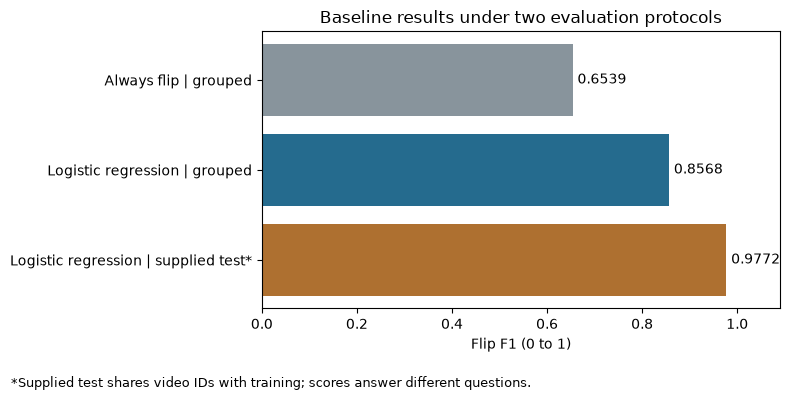

,comparison,absolute_f1_difference
0,Grouped F1 gain over reference,0.2029
1,Supplied test minus grouped F1,0.1204


Evidence exported to reports/; model and preview images remain in outputs/.


In [11]:
from datetime import datetime, timezone
import importlib.metadata
import shutil
from sklearn.metrics import confusion_matrix

REPORTS = ROOT / "reports"
REPORTS.mkdir(exist_ok=True)

manifest = df.copy()
manifest["path"] = manifest["path"].map(lambda p: p.relative_to(ROOT).as_posix())
manifest.to_csv(REPORTS / "dataset_manifest.csv", index=False)

oof = train[["path", "video_id", "frame", "label", "target"]].copy()
oof["path"] = oof["path"].map(lambda p: p.relative_to(ROOT).as_posix())
oof["fold"] = -1
for fold, (_, val_idx) in enumerate(folds, start=1):
    oof.loc[val_idx, "fold"] = fold
for name, pred in oof_predictions.items():
    oof[name + "_prediction"] = pred
assert oof.groupby("video_id")["fold"].nunique().eq(1).all()
assert oof["fold"].between(1, 5).all()
oof.to_csv(REPORTS / "validation_predictions.csv", index=False)
predictions.to_csv(REPORTS / "test_predictions.csv", index=False)
validation_results.to_csv(REPORTS / "validation_metrics.csv")
fold_scores.to_csv(REPORTS / "fold_metrics.csv", index=False)
pd.DataFrame(fold_details).to_csv(REPORTS / "fold_summary.csv", index=False)

cm = confusion_matrix(y_train, oof_predictions["logistic_pixels"], labels=[0, 1])
pd.DataFrame(cm, index=CLASS_NAMES, columns=CLASS_NAMES).rename_axis("actual").to_csv(
    REPORTS / "validation_confusion_matrix.csv")
shutil.copy2(OUTPUT / "validation_confusion_matrix.png", REPORTS / "validation_confusion_matrix.png")

pooled = float(validation_results.loc["logistic_pixels", "pooled_oof_f1"])
reference = float(validation_results.loc["always_flip", "pooled_oof_f1"])
gain = pooled - reference
protocol_gap = test_metrics["f1"] - pooled
notebook_source = json.loads((ROOT / "01_monreader_baseline.ipynb").read_text(encoding="utf-8"))
code_text = "\n\n".join("".join(c["source"]) for c in notebook_source["cells"] if c["cell_type"] == "code")
manifest_digest = hashlib.sha256((REPORTS / "dataset_manifest.csv").read_bytes()).hexdigest()
summary = {
    "reproduced_at_utc": datetime.now(timezone.utc).isoformat(),
    "scope": "Fixed single-image logistic-regression baseline; no deployment or sequence evaluation",
    "data": {"images": len(df), "training_images": len(train), "testing_images": len(test),
             "unique_video_ids": int(df["video_id"].nunique()), "shared_video_ids": len(shared_videos),
             "duplicate_file_hashes": int(df["sha256"].duplicated().sum()),
             "shared_exact_hashes": len(shared_hashes), "manifest_sha256": manifest_digest},
    "protocol": {"group": "filename video_id", "folds": 5, "seed": SEED,
                 "positive_label": "flip", "probability_threshold": 0.5,
                 "group_provenance_independently_verified": False},
    "model": {"features": "flattened grayscale pixels / 255", "image_size_width_height": list(IMAGE_SIZE),
              "scaler": "StandardScaler fitted within each fold", "classifier": "LogisticRegression",
              "C": 0.01, "solver": "liblinear", "max_iter": 2000},
    "grouped_validation": validation_results.to_dict(orient="index"),
    "supplied_test": test_metrics,
    "validation_confusion_matrix": {"label_order": CLASS_NAMES, "rows_actual_columns_predicted": cm.tolist()},
    "comparisons": {"grouped_f1_gain_over_always_flip": gain,
                    "supplied_test_minus_grouped_f1": protocol_gap,
                    "gap_interpretation": "Different protocols and fitting-set sizes; not a causal leakage estimate"},
    "environment": {"python": platform.python_version(), **{name: importlib.metadata.version(name) for name in
                    ["numpy", "pandas", "Pillow", "scikit-learn", "scipy", "matplotlib", "joblib", "threadpoolctl"]}},
    "notebook_code_sha256": hashlib.sha256(code_text.encode("utf-8")).hexdigest(),
}
_ = (REPORTS / "metrics.json").write_text(json.dumps(summary, indent=2), encoding="utf-8")

fig, ax = plt.subplots(figsize=(8, 4))
values = [reference, pooled, test_metrics["f1"]]
positions = np.arange(3)
ax.barh(positions, values, color=["#88949c", "#256b8e", "#ae7030"])
ax.set_yticks(positions, ["Always flip | grouped", "Logistic regression | grouped", "Logistic regression | supplied test*"])
ax.invert_yaxis()
ax.set_xlim(0, 1.09)
ax.set_xlabel("Flip F1 (0 to 1)")
ax.set_title("Baseline results under two evaluation protocols")
for position, value in zip(positions, values):
    ax.text(value + 0.01, position, f"{value:.4f}", va="center")
fig.text(0.02, 0.02, "*Supplied test shares video IDs with training; scores answer different questions.", fontsize=9)
fig.tight_layout(rect=[0, 0.07, 1, 1])
fig.savefig(REPORTS / "f1_comparison.png", dpi=150)
plt.show()

result_text = f"""# Reproduced baseline results

Binary F1 treats `flip` as the positive class. Grouped values use pooled out-of-fold predictions.

| Evaluation | Flip F1 | Precision | Recall |
| --- | ---: | ---: | ---: |
| Always flip, grouped validation | {reference:.4f} | {validation_results.loc['always_flip', 'precision']:.4f} | 1.0000 |
| Logistic regression, grouped validation | {pooled:.4f} | {validation_results.loc['logistic_pixels', 'precision']:.4f} | {validation_results.loc['logistic_pixels', 'recall']:.4f} |
| Logistic regression, supplied test | {test_metrics['f1']:.4f} | {test_metrics['precision']:.4f} | {test_metrics['recall']:.4f} |

Grouped F1 gain over the always-flip reference: **{gain:.4f}**, or **{gain * 100:.2f} percentage points** on the 0-100 F1 scale.

Grouped fold mean: **{validation_results.loc['logistic_pixels', 'fold_mean_f1']:.4f}**; sample standard deviation: **{validation_results.loc['logistic_pixels', 'fold_std_f1']:.4f}**. This standard deviation is not a confidence interval.

Grouped confusion counts: TN={cm[0,0]}, FP={cm[0,1]}, FN={cm[1,0]}, TP={cm[1,1]}.

The supplied-test score exceeds the pooled grouped score by {protocol_gap:.4f}. All {len(shared_videos)} filename video IDs overlap the supplied folders. These protocols evaluate different frames and fit on different amounts of data, so the gap is not an isolated causal estimate of leakage. Filename IDs are assumed to identify videos consistently; recording-session independence has not been established.

Source: [run metadata](metrics.json), [OOF predictions](validation_predictions.csv), [test predictions](test_predictions.csv), [fold scores](fold_metrics.csv), and [data manifest](dataset_manifest.csv). Regenerate by running the notebook from top to bottom. The exported predictions allow score recalculation without the source images.
"""
_ = (REPORTS / "results.md").write_text(result_text, encoding="utf-8")
display(pd.DataFrame({"comparison": ["Grouped F1 gain over reference", "Supplied test minus grouped F1"],
                      "absolute_f1_difference": [gain, protocol_gap]}).round(4))
print("Evidence exported to reports/; model and preview images remain in outputs/.")


## 10. Conclusions and next experiments

The baseline's pooled grouped F1 is **0.8568**, compared with **0.6539** for the always-flip rule: an absolute gain of **0.2029 F1** on the same folds. Flip precision is **0.8276** and recall is **0.8881**. The five fold scores range from **0.8040 to 0.9412**, so performance varies with the held-out groups.

The supplied benchmark yields **0.9772 F1**. Because its 65 video IDs also occur in training, that number should be labeled as the supplied frame benchmark wherever it appears. Grouped validation provides evidence about held-out video IDs, while neither protocol establishes performance on new devices, books, recording sessions, or real users.

The project produces an inspectable baseline, an explicit evaluation protocol, and saved evidence that can be used to compare future experiments. It does not yet quantify scanning quality, latency, calibration, or user benefit.

| Open question | Next experiment | Evidence needed |
| --- | --- | --- |
| Can better image features improve grouped F1? | Compare a convolutional or pretrained image model using training-only grouped validation | Same-group comparison, error counts, and variation across folds |
| Do predictions transfer to new capture conditions? | Collect independent videos with device/book/session metadata | An untouched external or session-disjoint evaluation set |
| Can temporal context resolve ambiguous frames? | Define labeled sequence windows and compare temporal features or a sequence model | Sequence-level metrics on videos excluded from fitting |
| Is the model suitable for a capture workflow? | Measure false-trigger cost and inference latency on a target device | Explicit operating requirements and measured trade-offs |

For a portfolio review, the work here can be assessed through the data audit, fold construction, preprocessing pipeline, baseline comparison, error inspection, and reproducible artifacts. Claims about further capabilities should follow additional experiments.

## References

- [Apziva](https://www.apziva.com/) and the [MonReader project brief](https://go.apziva.com/project/detail/21/) (brief may require sign-in).
- [StratifiedGroupKFold](https://scikit-learn.org/stable/modules/generated/sklearn.model_selection.StratifiedGroupKFold.html).
- [Pipelines and data leakage](https://scikit-learn.org/stable/common_pitfalls.html#data-leakage).
- [Logistic regression](https://scikit-learn.org/stable/modules/generated/sklearn.linear_model.LogisticRegression.html).
- [F1 score](https://scikit-learn.org/stable/modules/generated/sklearn.metrics.f1_score.html).

The repository uses the identifier required by the brief: [Abdulrahmanos/2ootcRDyofSiIM8i](https://github.com/Abdulrahmanos/2ootcRDyofSiIM8i). Apziva submission is a separate step.
